# 01 — Loan & Credit Data EDA

Explore the two production datasets used by the Bank Loan Approval & Customer Credit Risk Analysis application. This notebook is analysis-only and does not overwrite production models.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)

Project root: c:\Users\Dinesh more\OneDrive\Desktop\bank-loan-credit-risk-analysis\bank-loan-credit-risk-analysis


In [2]:
import pandas as pd
import numpy as np

loan = pd.read_csv(ROOT / 'data/raw/loan_data.csv')
risk = pd.read_csv(ROOT / 'data/raw/credit_risk_data.csv')
print('Loan shape:', loan.shape)
print('Risk shape:', risk.shape)

Loan shape: (12000, 29)
Risk shape: (12000, 23)


In [3]:
display(loan.head())
display(risk.head())
print('Loan dtypes:')
display(loan.dtypes.to_frame('dtype'))
print('Risk dtypes:')
display(risk.dtypes.to_frame('dtype'))

,customer_id,age,gender,marital_status,dependents,education,employment_type,monthly_income,annual_income,existing_loan,...,payment_history,credit_utilization,credit_score,loan_type,requested_loan_amount,loan_term,interest_rate,collateral_value,approved_loan_amount,loan_status
0,100001,41,Male,Single,0,Undergraduate,Business,50298.26,627344.77,No,...,59.76,0.5566,649,Education,541081.99,36,17.92,0.00,0.0,Rejected
1,100002,28,Male,Single,1,Graduate,Self-employed,50453.12,574514.47,No,...,98.48,0.3672,716,Education,92913.34,60,17.82,0.00,0.0,Rejected
2,100003,46,Male,Married,2,Undergraduate,Self-employed,134008.81,1518957.11,No,...,54.76,0.2295,714,Business,576382.66,72,16.90,925196.08,0.0,Rejected
3,100004,47,Male,Single,1,Undergraduate,Self-employed,111267.73,1227600.25,Yes,...,100.00,0.3051,743,Personal,529402.80,36,16.12,0.00,0.0,Rejected
4,100005,21,Female,Married,2,Graduate,Salaried,58334.06,710158.92,No,...,72.54,0.3428,642,Personal,863505.60,36,15.62,0.00,0.0,Rejected


,customer_id,age,gender,marital_status,dependents,education,employment_type,monthly_income,annual_income,existing_loan,...,savings,bank_balance,assets,credit_history,previous_loans,previous_defaults,payment_history,credit_utilization,credit_score,risk_level
0,100001,41,Male,Single,0,Undergraduate,Business,50298.26,627344.77,No,...,1896874.57,1790431.71,447999.88,Good,1,0,59.76,0.5566,649,High
1,100002,28,Male,Single,1,Graduate,Self-employed,50453.12,574514.47,No,...,565833.48,480289.33,2115525.57,Good,3,0,98.48,0.3672,716,Medium
2,100003,46,Male,Married,2,Undergraduate,Self-employed,134008.81,1518957.11,No,...,348160.24,212884.56,225696.99,Average,4,0,54.76,0.2295,714,High
3,100004,47,Male,Single,1,Undergraduate,Self-employed,111267.73,1227600.25,Yes,...,653907.24,638333.65,1726396.04,Good,4,0,100.00,0.3051,743,Medium
4,100005,21,Female,Married,2,Graduate,Salaried,58334.06,710158.92,No,...,251338.93,183055.09,7358654.18,Average,0,1,72.54,0.3428,642,High


Loan dtypes:


,dtype
customer_id,int64
age,int64
gender,object
marital_status,object
dependents,int64
education,object
employment_type,object
monthly_income,float64
annual_income,float64
existing_loan,object


Risk dtypes:


,dtype
customer_id,int64
age,int64
gender,object
marital_status,object
dependents,int64
education,object
employment_type,object
monthly_income,float64
annual_income,float64
existing_loan,object


In [4]:
def quality_report(df):
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (df.isna().mean()*100).round(2),
        'unique': df.nunique(dropna=False),
    }).sort_values(['missing','unique'], ascending=[False, True])

print('Loan quality')
display(quality_report(loan))
print('Risk quality')
display(quality_report(risk))

Loan quality


,dtype,missing,missing_pct,unique
payment_history,float64,120,1.0,4403
credit_utilization,float64,120,1.0,5370
monthly_income,float64,120,1.0,11862
gender,object,0,0.0,2
existing_loan,object,0,0.0,2
loan_status,object,0,0.0,2
marital_status,object,0,0.0,3
education,object,0,0.0,3
credit_history,object,0,0.0,3
employment_type,object,0,0.0,4


Risk quality


,dtype,missing,missing_pct,unique
payment_history,float64,120,1.0,4403
credit_utilization,float64,120,1.0,5372
monthly_income,float64,120,1.0,11862
gender,object,0,0.0,2
existing_loan,object,0,0.0,2
marital_status,object,0,0.0,3
education,object,0,0.0,3
credit_history,object,0,0.0,3
risk_level,object,0,0.0,3
employment_type,object,0,0.0,4


In [5]:
print('Duplicate rows — loan:', loan.duplicated().sum())
print('Duplicate rows — risk:', risk.duplicated().sum())
print('Loan status distribution')
display(loan['loan_status'].value_counts(dropna=False).to_frame('count'))
print('Risk level distribution')
display(risk['risk_level'].value_counts(dropna=False).to_frame('count'))

Duplicate rows — loan: 0
Duplicate rows — risk: 0
Loan status distribution


,count
loan_status,
Rejected,9318
Approved,2682


Risk level distribution


,count
risk_level,
High,8949
Medium,2603
Low,448


In [6]:
numeric_checks = ['age','annual_income','monthly_debt','savings','bank_balance','assets','credit_score','requested_loan_amount','loan_term','collateral_value','interest_rate']
checks=[]
for c in numeric_checks:
    if c in loan.columns:
        s=pd.to_numeric(loan[c], errors='coerce')
        checks.append({'dataset':'loan','column':c,'min':s.min(),'max':s.max(),'negative_count':int((s<0).sum())})
    if c in risk.columns:
        s=pd.to_numeric(risk[c], errors='coerce')
        checks.append({'dataset':'risk','column':c,'min':s.min(),'max':s.max(),'negative_count':int((s<0).sum())})
display(pd.DataFrame(checks))

,dataset,column,min,max,negative_count
0,loan,age,21.00,70.00,0
1,risk,age,21.00,70.00,0
2,loan,annual_income,131837.45,9370379.41,0
3,risk,annual_income,131837.45,9370379.41,0
4,loan,monthly_debt,117.28,381159.69,0
5,risk,monthly_debt,117.28,381159.69,0
6,loan,savings,8036.52,22368509.55,0
7,risk,savings,8036.52,22368509.55,0
8,loan,bank_balance,2000.00,8057382.99,0
9,risk,bank_balance,2000.00,8057382.99,0


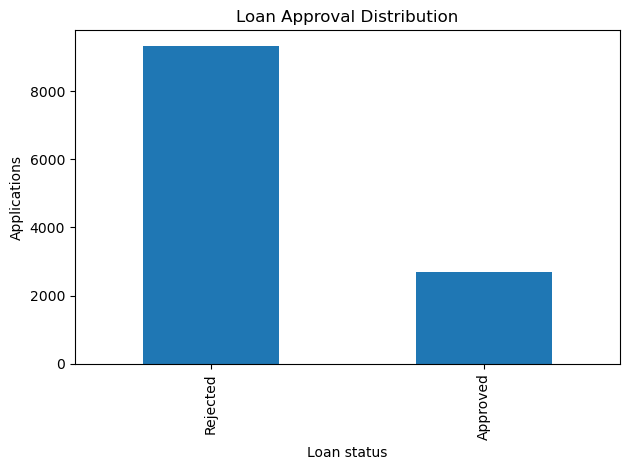

In [7]:
import matplotlib.pyplot as plt

loan['loan_status'].value_counts().plot(kind='bar', title='Loan Approval Distribution')
plt.xlabel('Loan status'); plt.ylabel('Applications'); plt.tight_layout(); plt.show()

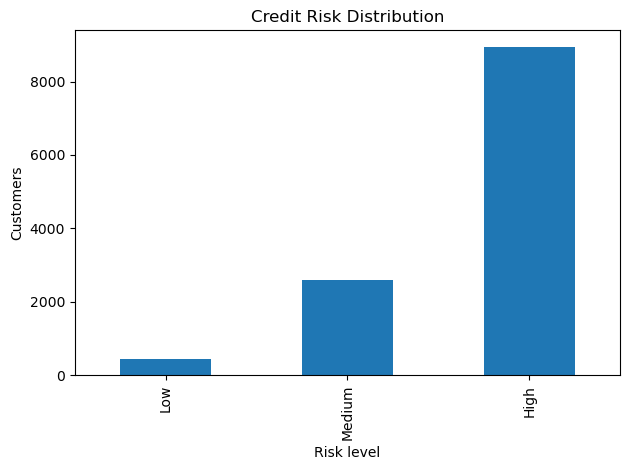

In [8]:
risk['risk_level'].value_counts().reindex(['Low','Medium','High']).plot(kind='bar', title='Credit Risk Distribution')
plt.xlabel('Risk level'); plt.ylabel('Customers'); plt.tight_layout(); plt.show()

## Interpretation
Use these checks to understand data quality, class balance, and suspicious values before modeling. Production training remains centralized in `src/train.py`.